In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import copy

from skimage.metrics import structural_similarity, mean_squared_error

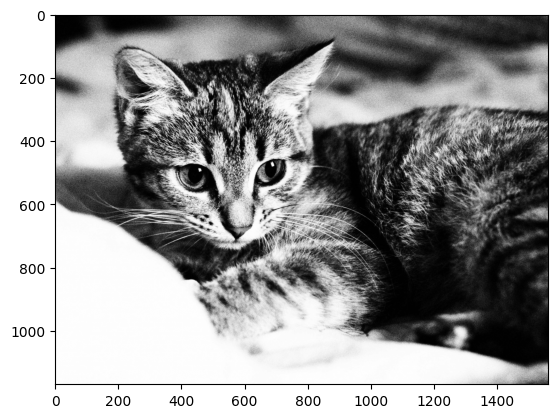

In [37]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap="gray")

In [38]:
#гауссовский шума
mean = 0
stddev = 50
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[  0,   0,   0, ...,  89, 116,   0],
       [ 28,  34,   0, ...,   0,   0,   0],
       [  0,  85,   8, ...,   5,  47,   0],
       ...,
       [  0,   0,   5, ...,   0,  40,  56],
       [ 28,   0,   0, ...,  19,   0,  37],
       [  0,  88,  79, ...,  35,  39,   0]], dtype=uint8)

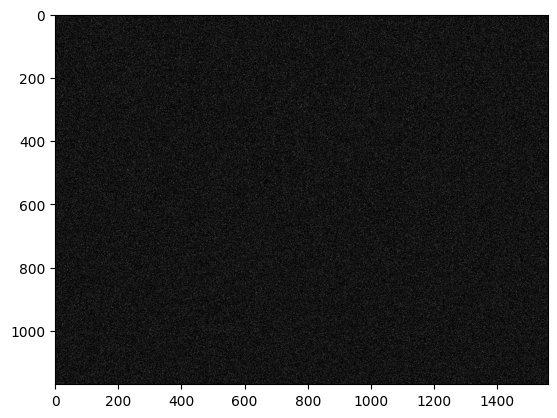

In [39]:
plt.imshow(noise_gauss, cmap="gray")

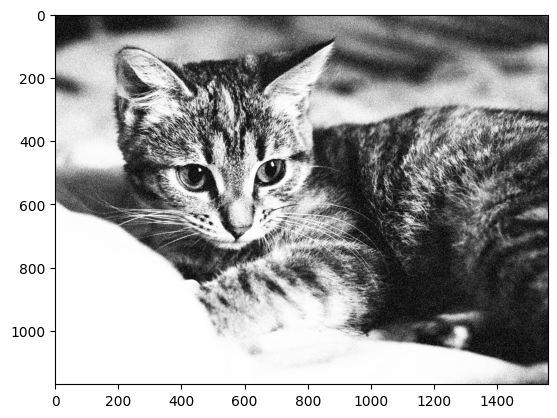

In [40]:
#Зашумление изображения

image_noise_gauss = cv2.add(image_gray, noise_gauss)
plt.imshow(image_noise_gauss, cmap="gray")

In [41]:
#добавление постоянного шума
noise = np.random.randint(0, 101, size=(image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel = np.where(noise == 100)

In [42]:
image_sp = copy.deepcopy(image_gray)

image_sp[zeros_pixel] = 0
image_sp[ones_pixel] = 255

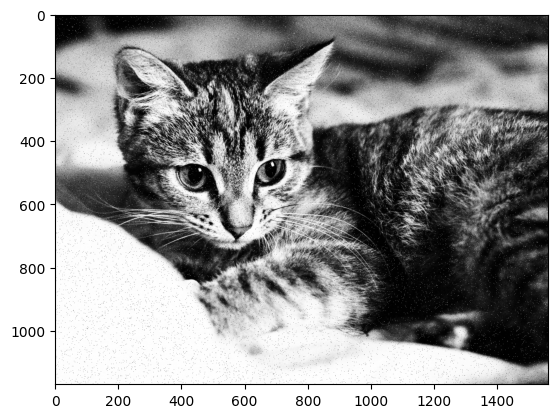

In [43]:
plt.imshow(image_sp, cmap="gray")

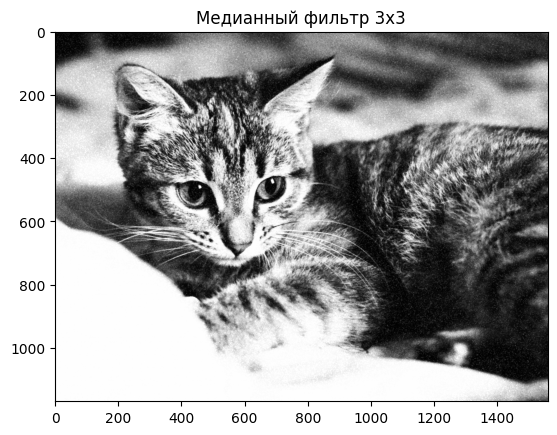

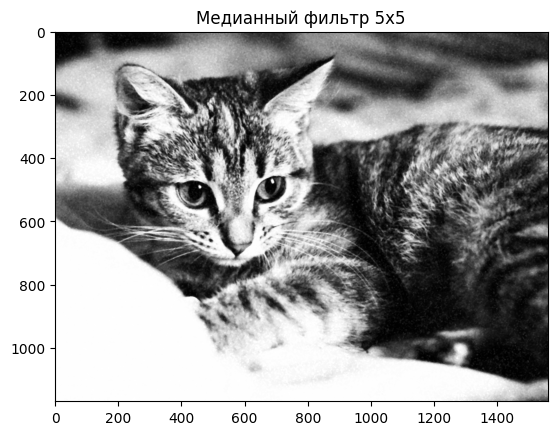

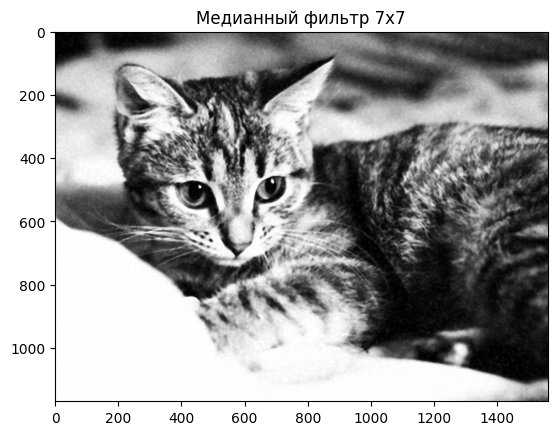

In [44]:
#Медианный фильтр
image_median = cv2.medianBlur(image_noise_gauss, 3)
image_median_5 = cv2.medianBlur(image_noise_gauss, 5)
image_median_7 = cv2.medianBlur(image_noise_gauss, 7)

plt.imshow(image_median, cmap='gray')
plt.title('Медианный фильтр 3x3')
plt.show()

plt.imshow(image_median_5, cmap='gray')
plt.title('Медианный фильтр 5x5')
plt.show()

plt.imshow(image_median_7, cmap='gray')
plt.title('Медианный фильтр 7x7')
plt.show()

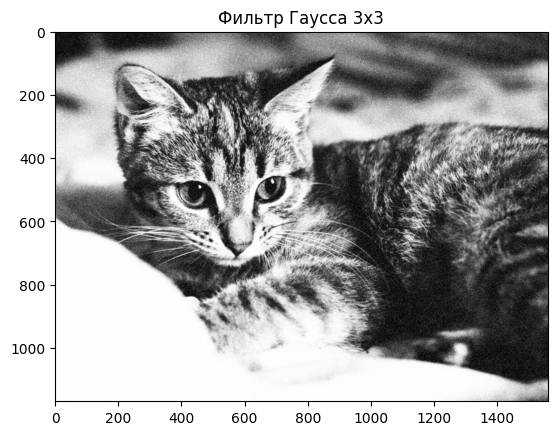

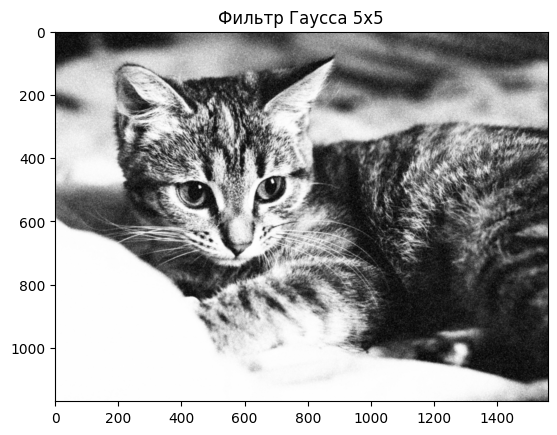

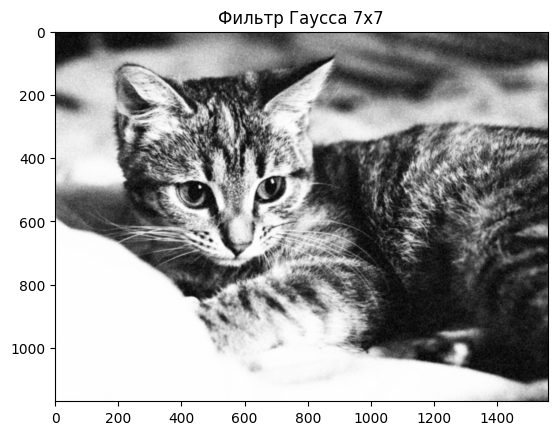

In [45]:
#Фильтр Гаусса
image_gauss = cv2.GaussianBlur(image_noise_gauss, (3,3), 0)
image_gauss_5 = cv2.GaussianBlur(image_noise_gauss, (5,5), 0)
image_gauss_7 = cv2.GaussianBlur(image_noise_gauss, (7,7), 0)

plt.imshow(image_gauss, cmap='gray')
plt.title('Фильтр Гаусса 3x3')
plt.show()

plt.imshow(image_gauss_5, cmap='gray')
plt.title('Фильтр Гаусса 5x5')
plt.show()

plt.imshow(image_gauss_7, cmap='gray')
plt.title('Фильтр Гаусса 7x7')
plt.show()

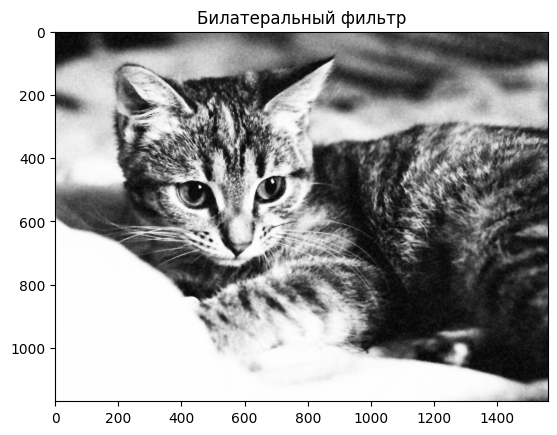

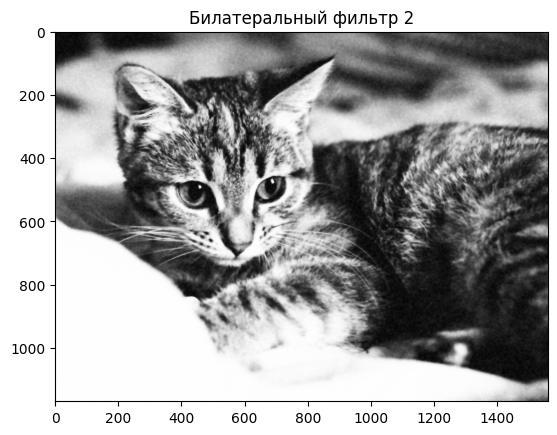

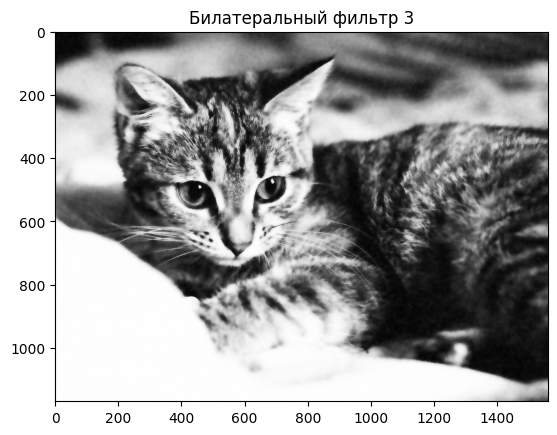

In [46]:
#Билатеральный фильтр
image_bilat = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)
image_bilat_2 = cv2.bilateralFilter(image_noise_gauss, 9, 100, 100)
image_bilat_3 = cv2.bilateralFilter(image_noise_gauss, 15, 75, 75)

plt.imshow(image_bilat, cmap='gray')
plt.title('Билатеральный фильтр')
plt.show()

plt.imshow(image_bilat_2, cmap='gray')
plt.title('Билатеральный фильтр 2')
plt.show()

plt.imshow(image_bilat_3, cmap='gray')
plt.title('Билатеральный фильтр 3')
plt.show()

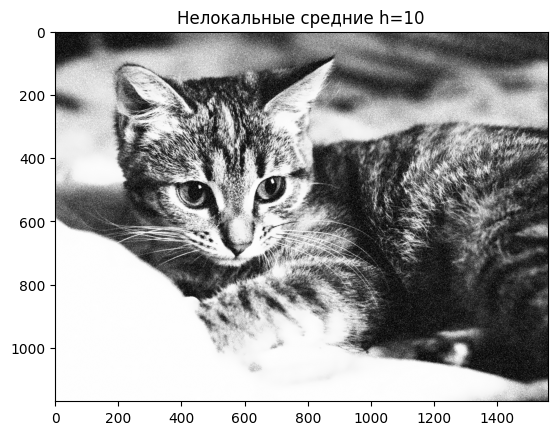

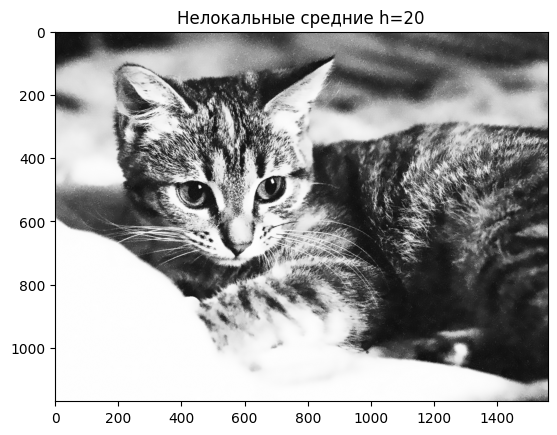

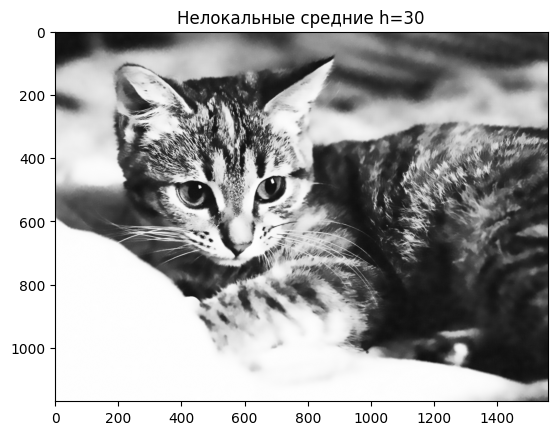

In [47]:
#Фильтр нелокальных средних
image_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h=10)
image_nlm_2 = cv2.fastNlMeansDenoising(image_noise_gauss, h=20)
image_nlm_3 = cv2.fastNlMeansDenoising(image_noise_gauss, h=30)

plt.imshow(image_nlm, cmap='gray')
plt.title('Нелокальные средние h=10')
plt.show()

plt.imshow(image_nlm_2, cmap='gray')
plt.title('Нелокальные средние h=20')
plt.show()

plt.imshow(image_nlm_3, cmap='gray')
plt.title('Нелокальные средние h=30')
plt.show()

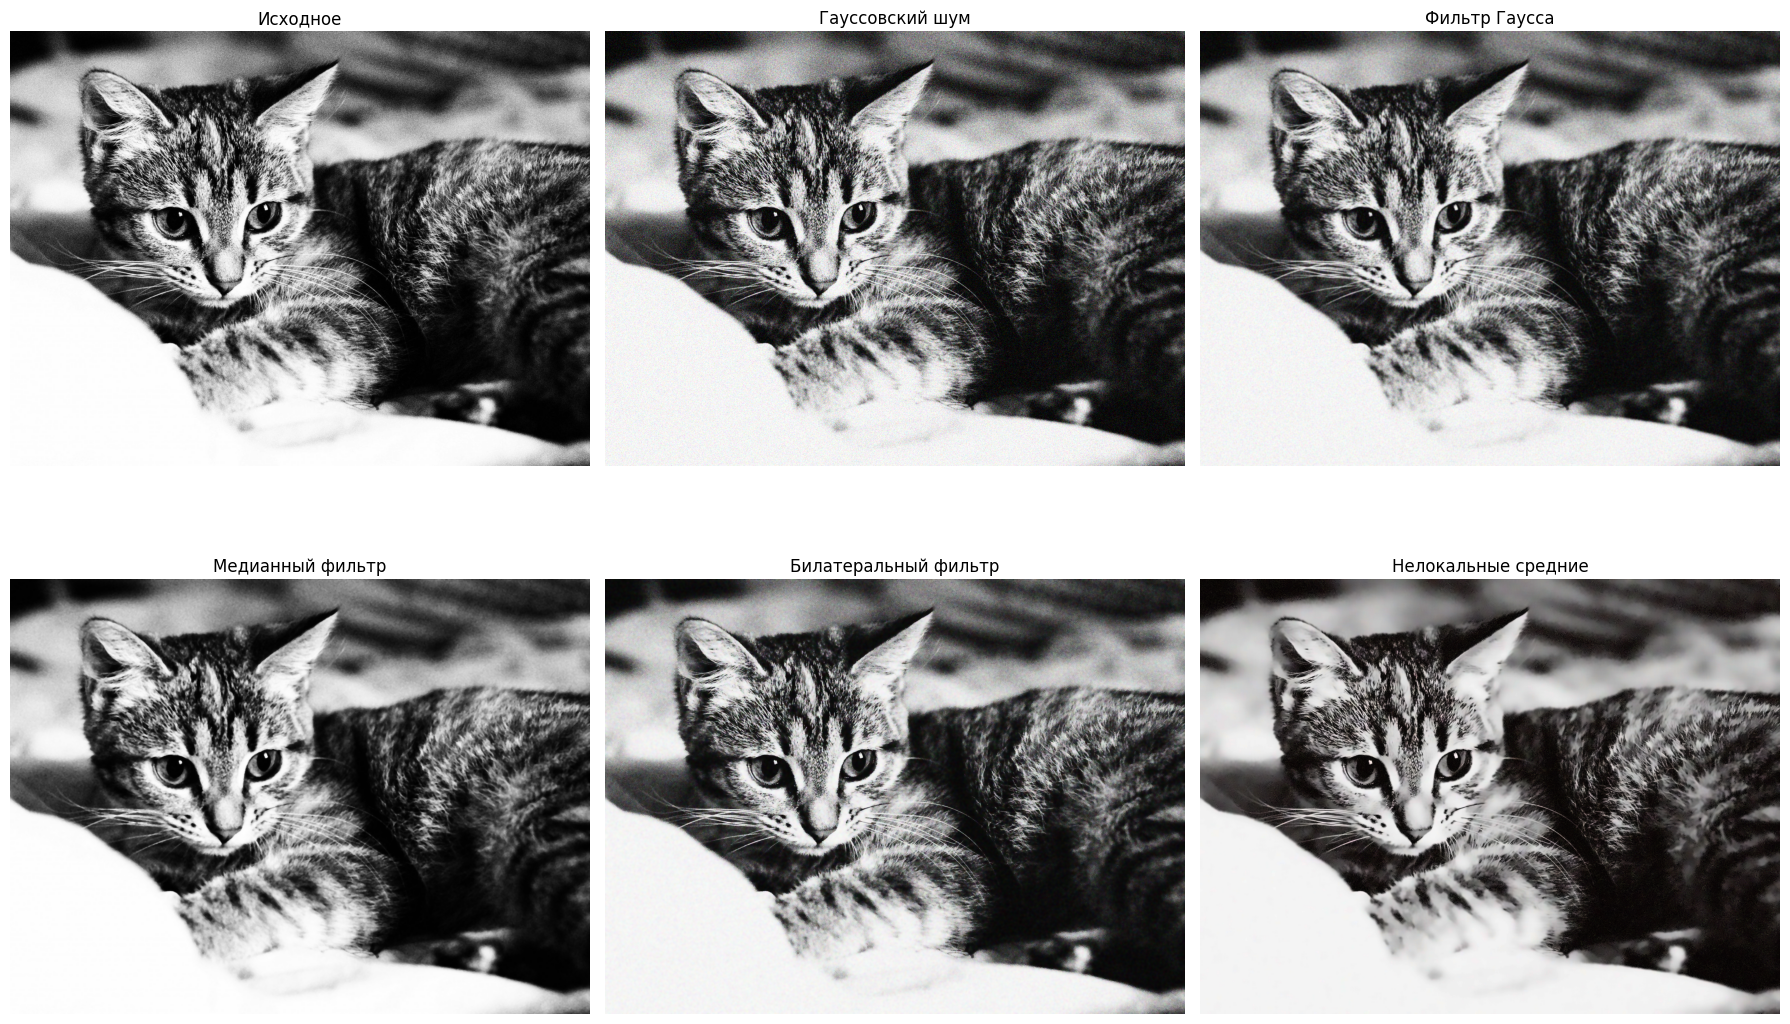

In [48]:
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Исходное')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(cv2.cvtColor(noisy_gaussian, cv2.COLOR_BGR2RGB))
plt.title('Гауссовский шум')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(cv2.cvtColor(gaussian_5, cv2.COLOR_BGR2RGB))
plt.title('Фильтр Гаусса')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(cv2.cvtColor(median_5, cv2.COLOR_BGR2RGB))
plt.title('Медианный фильтр')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(cv2.cvtColor(bilateral_2, cv2.COLOR_BGR2RGB))
plt.title('Билатеральный фильтр')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(cv2.cvtColor(nlm_2, cv2.COLOR_BGR2RGB))
plt.title('Нелокальные средние')
plt.axis('off')

plt.tight_layout()
plt.show()

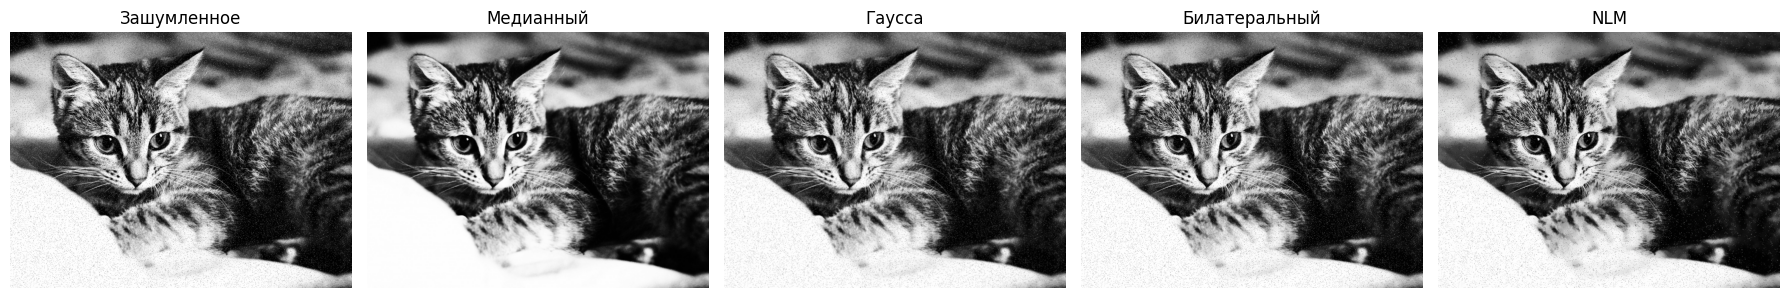

In [49]:
median_constant = cv2.medianBlur(noisy_constant, 5)

gaussian_constant = cv2.GaussianBlur(
    noisy_constant,
    (5, 5),
    0
)

bilateral_constant = cv2.bilateralFilter(
    noisy_constant,
    9,
    75,
    75
)

nlm_constant = cv2.fastNlMeansDenoisingColored(
    noisy_constant,
    None,
    h=20,
    hColor=20,
    templateWindowSize=7,
    searchWindowSize=21
)

plt.figure(figsize=(18, 5))

plt.subplot(1, 5, 1)
plt.imshow(cv2.cvtColor(noisy_constant, cv2.COLOR_BGR2RGB))
plt.title('Зашумленное')
plt.axis('off')

plt.subplot(1, 5, 2)
plt.imshow(cv2.cvtColor(median_constant, cv2.COLOR_BGR2RGB))
plt.title('Медианный')
plt.axis('off')

plt.subplot(1, 5, 3)
plt.imshow(cv2.cvtColor(gaussian_constant, cv2.COLOR_BGR2RGB))
plt.title('Гаусса')
plt.axis('off')

plt.subplot(1, 5, 4)
plt.imshow(cv2.cvtColor(bilateral_constant, cv2.COLOR_BGR2RGB))
plt.title('Билатеральный')
plt.axis('off')

plt.subplot(1, 5, 5)
plt.imshow(cv2.cvtColor(nlm_constant, cv2.COLOR_BGR2RGB))
plt.title('NLM')
plt.axis('off')

plt.tight_layout()
plt.show()